#### 1. Monthly Revenue Line Chart
#### Using order_date and revenue:
#### • Convert order_date to datetime.
#### • Calculate total revenue for each month.
#### • Create a line chart.
#### • Add:
#### o Title
#### o X-axis label
#### o Y-axis label
#### o Grid
#### o Markers

#### Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

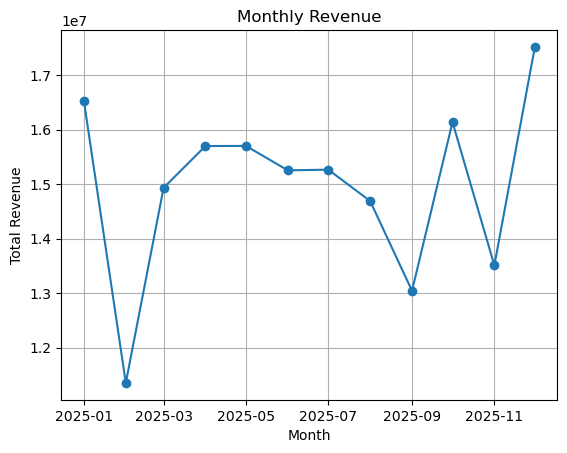

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cleaned_messy_sales_data.csv")


df['order_date'] = pd.to_datetime(df['order_date'])

monthly_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['revenue'].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()


plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')


plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)

#### 2. Monthly Profit Line Chart
#### Create a line chart showing monthly Profit.
#### Requirements:
#### • Use a different line style.
#### • Add markers.
#### • Add a legend.
#### • Display the value of the highest-profit month using annotate().
#### Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

NameError: name 'highest_profit' is not defined

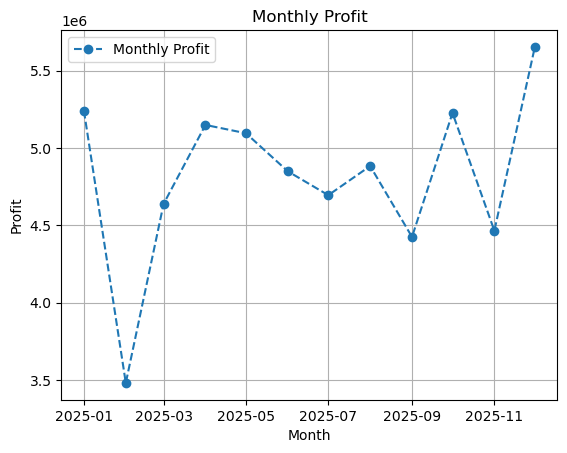

In [21]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_profit = df.groupby(
    df['order_date'].dt.to_period('M')
)['profit'].sum()


monthly_profit.index = monthly_profit.index.to_timestamp()


highest_month = monthly_profit.idxmax()


highest_month  = monthly_profit.max()

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    linestyle='--',
    marker='o',
    label='Monthly Profit'
)

plt.title('Monthly Profit')

plt.xlabel('Month')

plt.ylabel('Profit')

plt.grid(True)

plt.legend()

plt.annotate(
    f'Highest Profit: {highest_profit:.2f}',
    xy=(highest_month, highest_profit),
    xytext=(10, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)


plt.show()

#### 3. Revenue by Product Category — Bar Chart
#### Calculate total revenue for each product_category.
#### Create a bar chart.
#### Requirements:
#### • X-axis → Product Category
#### • Y-axis → Revenue
#### • Add title and labels.
#### • Display the revenue value above each bar.
#### Commands/concepts: plt.bar(), plt.text()

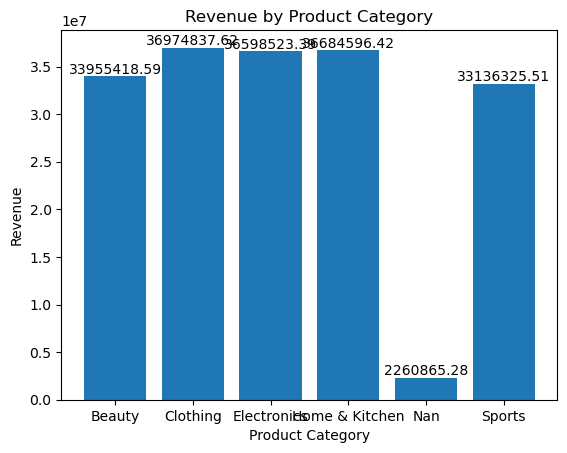

In [22]:
category_revenue = df.groupby('product_category')['revenue'].sum()


plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')

plt.xlabel('Product Category')

plt.ylabel('Revenue')

for i, value in enumerate(category_revenue.values):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### 4. Profit by City — Horizontal Bar Chart
#### Calculate total profit for each city.
#### Create a horizontal bar chart.
#### Requirements:
#### • Sort cities by profit.
#### • Show the highest-profit city first.
#### • Add title and axis labels.
#### Commands/concepts: plt.barh(), sort_values()

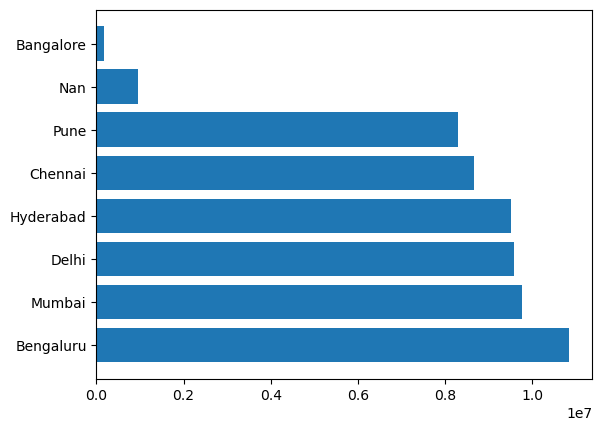

In [23]:
city_profit = df.groupby('city')['profit'].sum()

city_profit = city_profit.sort_values(ascending=False)

plt.barh(city_profit.index, city_profit.values)

plt.show()

#### 5. Customer Age Histogram
#### Create a histogram of the age column.
#### Requirements:
#### • Use 10 bins.
#### • Add title.
#### • Add X/Y labels.
#### • Add grid.
#### • Add a vertical line showing the median age.
#### Commands/concepts: plt.hist(), plt.axvline()

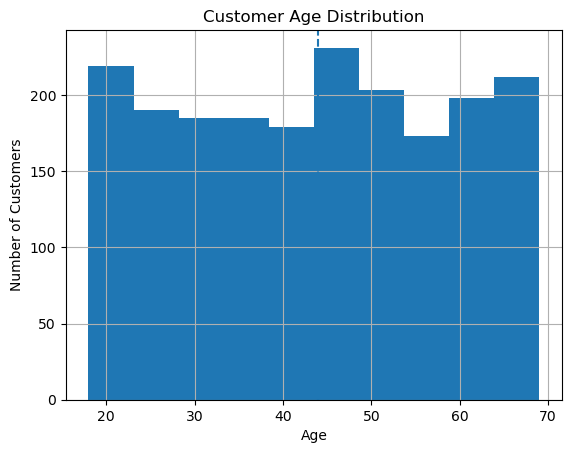

In [24]:
median_age = df['age'].median()

plt.hist(df['age'].dropna(), bins=10)

plt.title('Customer Age Distribution')

plt.xlabel('Age')

plt.ylabel('Number of Customers')

plt.grid(True)

plt.axvline(median_age, linestyle='--',
            label=f'Median Age: {median_age:.0f}')

plt.show()

#### 6. Revenue Distribution Histogram
#### Create a histogram showing the distribution of revenue.
#### Requirements:
#### • Use 20 bins.
#### • Add transparency using alpha.
#### • Add grid.
#### • Add mean and median lines.
#### • Add a legend.
#### Commands/concepts:
#### plt.hist()
#### plt.axvline()
#### plt.legend()

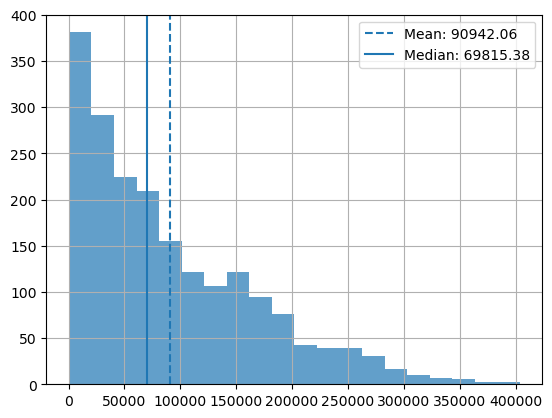

In [25]:
mean_revenue = df['revenue'].mean()
median_revenue = df['revenue'].median()

plt.hist(df['revenue'].dropna(), bins=20, alpha=0.7)

plt.axvline(
    mean_revenue,
    linestyle='--',
    label=f'Mean: {mean_revenue:.2f}'
)

plt.axvline(
    median_revenue,
    linestyle='-',
    label=f'Median: {median_revenue:.2f}'
)

plt.grid(True)

plt.legend()

plt.show()

#### 7. Revenue vs Profit Scatter Plot
#### Create a scatter plot between:
#### • X → Revenue
#### • Y → Profit
#### Requirements:
#### • Use different marker size.
#### • Add transparency.
#### • Add title and axis labels.
#### • Add grid.
#### Commands/concepts:
#### plt.scatter()
#### Important parameters to practice:
#### s=
#### alpha=
#### marker=

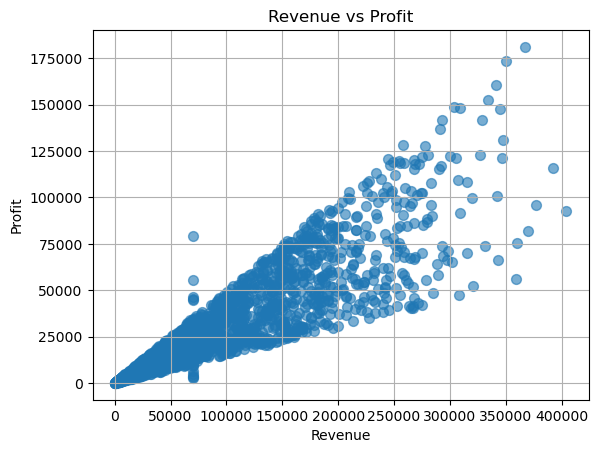

In [26]:
plt.scatter(
    df['revenue'],
    df['profit'],
    s=50,
    alpha=0.6,
    marker='o'
)

# Add title and labels
plt.title('Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')

# Add grid
plt.grid(True)

# Display chart
plt.show()

#### 8. Discount vs Profit Scatter Plot
#### Create a scatter plot between:
#### • X → discount_pct
#### • Y → profit
#### Requirements:
#### • Use a different marker.
#### • Add transparency.
#### • Add title.
#### • Add axis labels.
#### • Add grid.
#### Then answer:
#### Does profit appear to decrease as discount increases?

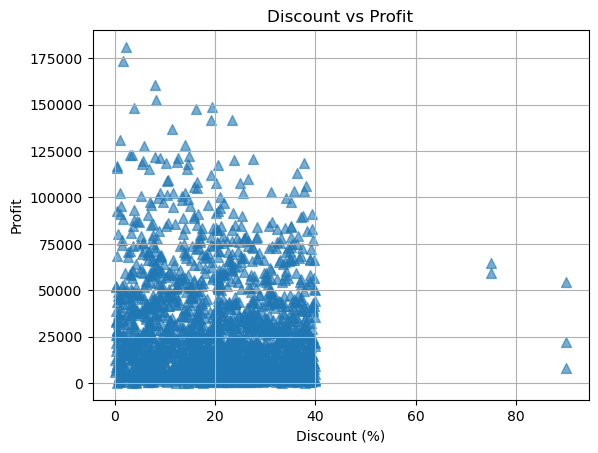

In [27]:
# Create scatter plot
plt.scatter(
    df['discount'],
    df['profit'],
    s=50,
    alpha=0.6,
    marker='^'
)

# Add title
plt.title('Discount vs Profit')

# Add axis labels
plt.xlabel('Discount (%)')
plt.ylabel('Profit')

# Add grid
plt.grid(True)

# Show chart
plt.show()

#### 9. Revenue Share — Pie Chart
#### Calculate total revenue for every product_category.
#### Create a pie chart showing each category's contribution.
#### Requirements:
#### • Display percentages.
#### • Display category names.
#### • Add a title.
#### • Start the first slice from the top.
#### Commands/concepts:
#### plt.pie()
#### Important parameters:
#### autopct=
#### startangle=
#### labels=

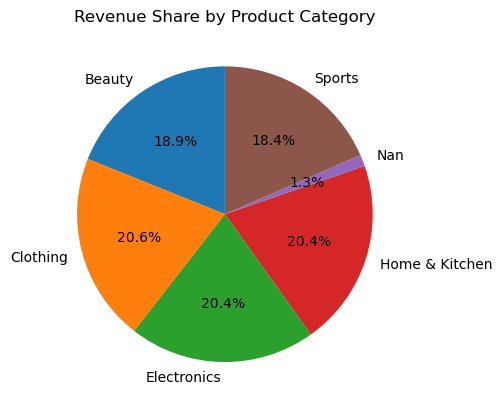

In [28]:
# Calculate total revenue for each product category
category_revenue = df.groupby('product_category')['revenue'].sum()

# Create pie chart
plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

# Add title
plt.title('Revenue Share by Product Category')

# Display chart
plt.show()

#### 10. Customer Segment Pie Chart 
#### Create a pie chart showing the number of customers/orders in each customer segment. 
#### Segments:  
#### • Premium 
#### • Regular 
#### • Budget 
#### Requirements: 
#### • Show percentage. 
#### • Add labels. 
#### • Add title. 
#### • Make the chart visually clean. 
#### Question: Which customer segment has the largest share?

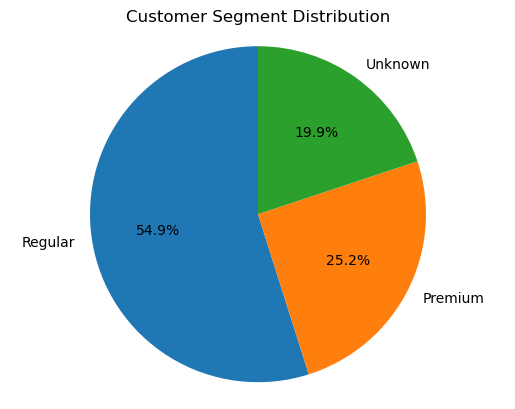

In [29]:
# Count customers/orders in each customer segment
segment_count = df['customer_segment'].value_counts()

# Create pie chart
plt.pie(
    segment_count.values,
    labels=segment_count.index,
    autopct='%1.1f%%',
    startangle=90
)

# Add title
plt.title('Customer Segment Distribution')

# Keep the pie chart circular
plt.axis('equal')

# Display chart
plt.show()

#### 11. Compare Revenue and Profit
#### Create a grouped bar chart for each product_category.
#### For every category show:
#### • Revenue
#### • Profit
#### Requirements:
#### • Two bars per category.
#### • Different colors.
#### • Add legend.
#### • Add title and axis labels.
#### Concepts: plt.bar(), bar positions, width, plt.xticks()

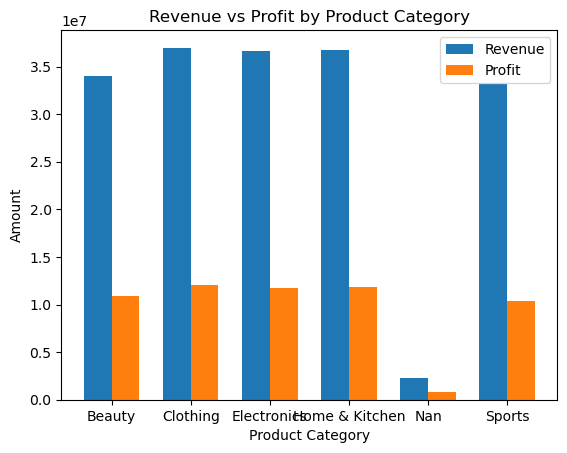

In [30]:
category_data = df.groupby('product_category')[['revenue', 'profit']].sum()

# Set bar positions
x = np.arange(len(category_data))
width = 0.35

# Revenue bars
plt.bar(
    x - width/2,
    category_data['revenue'],
    width,
    label='Revenue'
)

# Profit bars
plt.bar(
    x + width/2,
    category_data['profit'],
    width,
    label='Profit'
)

# Add category names
plt.xticks(x, category_data.index)

# Add title and labels
plt.title('Revenue vs Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount')

# Add legend
plt.legend()

# Show chart
plt.show()

#### 12. Monthly Revenue vs Profit 
#### Create a chart containing two lines: 
#### • Revenue 
#### • Profit 
#### for every month. 
#### Requirements:  
#### • Different colors. 
#### • Different markers. 
#### • Different line styles. 
#### • Legend. 
#### • Grid. 
#### • Title. 
#### • X/Y labels. 
#### Example concept: 
#### plt.plot(months, revenue) 
#### plt.plot(months, profit)

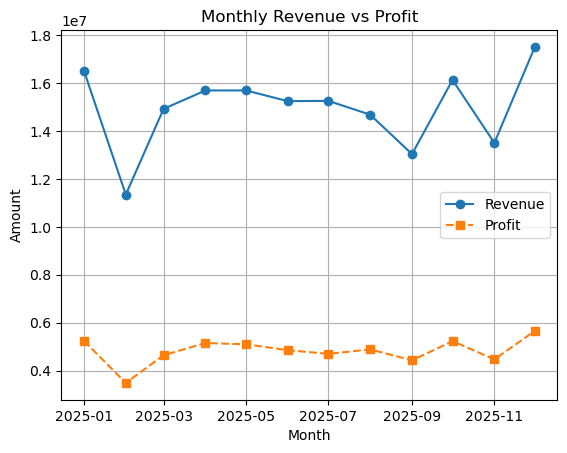

In [31]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate monthly revenue and profit
monthly_data = df.groupby(
    df['order_date'].dt.to_period('M')
)[['revenue', 'profit']].sum()

# Get months
months = monthly_data.index.to_timestamp()

# Revenue line
plt.plot(
    months,
    monthly_data['revenue'],
    marker='o',
    linestyle='-',
    label='Revenue'
)

# Profit line
plt.plot(
    months,
    monthly_data['profit'],
    marker='s',
    linestyle='--',
    label='Profit'
)

# Title and labels
plt.title('Monthly Revenue vs Profit')
plt.xlabel('Month')
plt.ylabel('Amount')

# Grid and legend
plt.grid(True)
plt.legend()

# Show chart
plt.show()

#### 13. Sales Channel Comparison
#### Calculate total revenue for:
#### • Online
#### • Retail
#### • Corporate
#### Create a bar chart.
#### Requirements:
#### • Add value labels on bars.
#### • Sort from highest to lowest.
#### • Add title.
#### • Add axis labels.
#### • Add grid.
#### Question: Which sales channel generates the highest revenue?

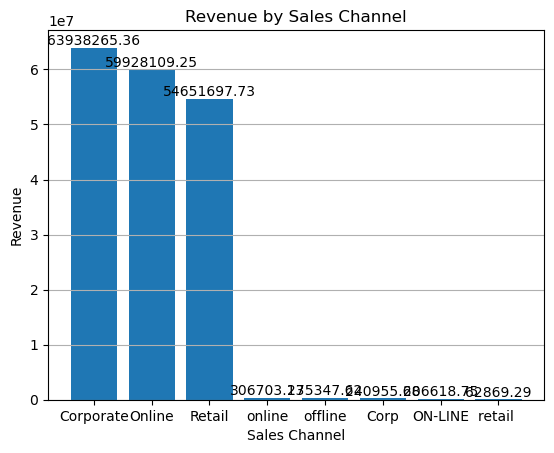

In [32]:
# Calculate total revenue for each sales channel
channel_revenue = df.groupby('sales_channel')['revenue'].sum()

# Sort from highest to lowest
channel_revenue = channel_revenue.sort_values(ascending=False)

# Create bar chart
plt.bar(
    channel_revenue.index,
    channel_revenue.values
)

# Add revenue values above bars
for i, value in enumerate(channel_revenue.values):
    plt.text(
        i,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

# Add title and labels
plt.title('Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Revenue')

# Add grid
plt.grid(True, axis='y')

# Show chart
plt.show()

#### 14. Four-Chart Matplotlib Dashboard 
#### Create a 2 × 2 subplot. 
#### Chart 1  
#### Monthly Revenue → Line chart 
#### Chart 2 
#### Revenue by Category → Bar chart 
#### Chart 3 
#### Customer Age → Histogram 
#### Chart 4 
#### Revenue vs Profit → Scatter plot 
#### Use: 
#### plt.subplots(2, 2) 
#### Give every subplot: 
#### • Its own title 
#### • Appropriate labels 
#### • Grid where useful 
#### Finally use: 
#### plt.tight_layout()

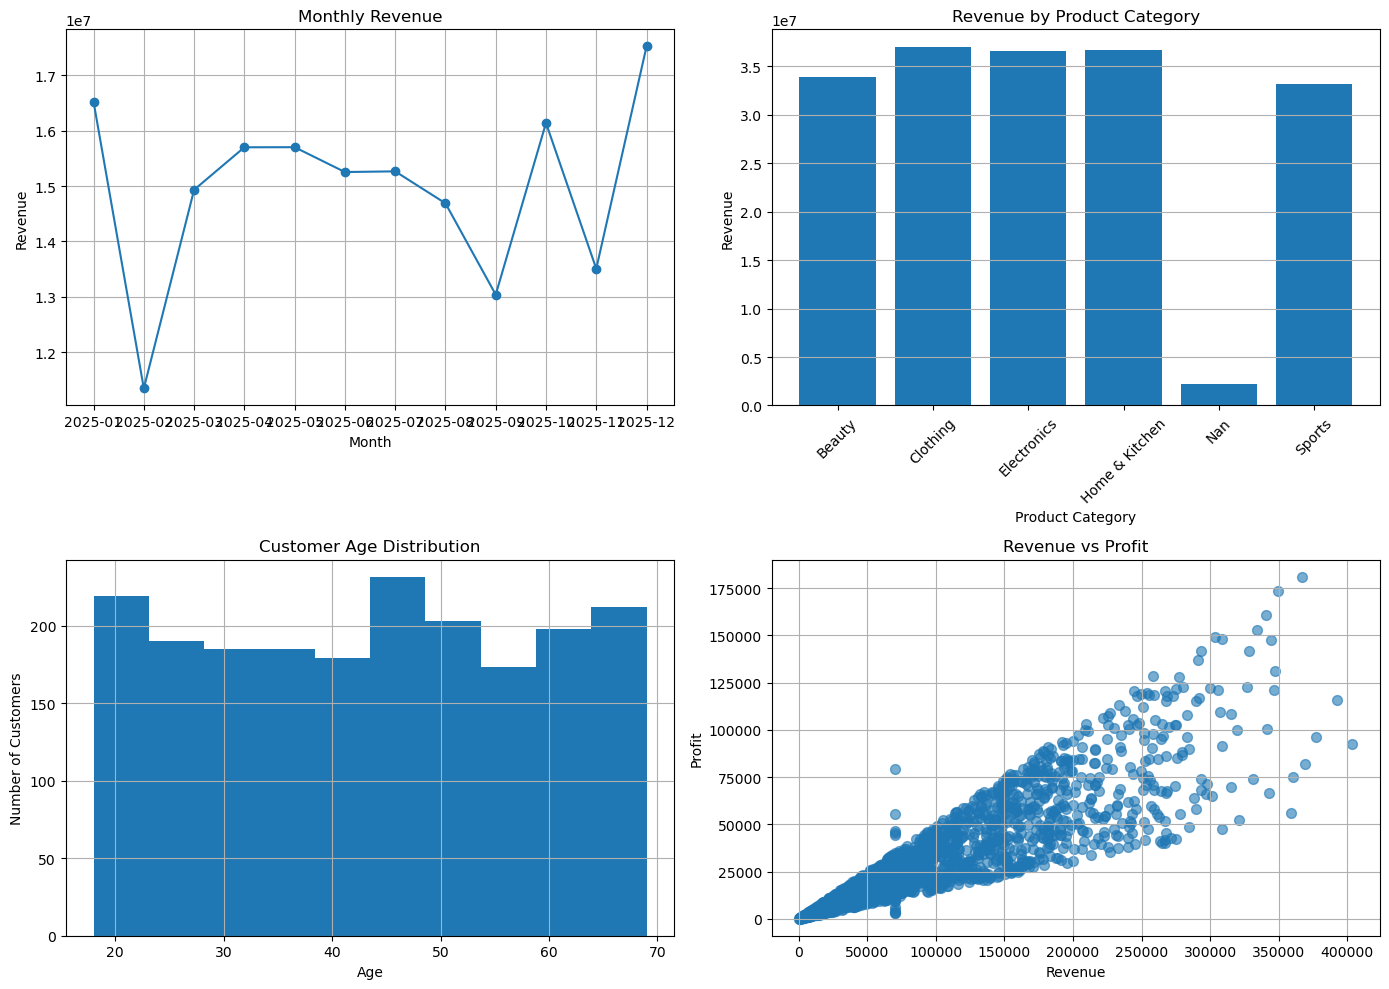

In [33]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate monthly revenue
monthly_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['revenue'].sum()

# Calculate revenue by product category
category_revenue = df.groupby(
    'product_category'
)['revenue'].sum()

# Create 2 x 2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# -----------------------------
# Chart 1: Monthly Revenue
# -----------------------------
axes[0, 0].plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o'
)

axes[0, 0].set_title('Monthly Revenue')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue')
axes[0, 0].grid(True)


# -----------------------------
# Chart 2: Revenue by Category
# -----------------------------
axes[0, 1].bar(
    category_revenue.index,
    category_revenue.values
)

axes[0, 1].set_title('Revenue by Product Category')
axes[0, 1].set_xlabel('Product Category')
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, axis='y')


# -----------------------------
# Chart 3: Customer Age
# -----------------------------
axes[1, 0].hist(
    df['age'].dropna(),
    bins=10
)

axes[1, 0].set_title('Customer Age Distribution')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].grid(True)


# -----------------------------
# Chart 4: Revenue vs Profit
# -----------------------------
axes[1, 1].scatter(
    df['revenue'],
    df['profit'],
    s=50,
    alpha=0.6,
    marker='o'
)

axes[1, 1].set_title('Revenue vs Profit')
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Profit')
axes[1, 1].grid(True)


# Adjust spacing
plt.tight_layout()

# Show dashboard
plt.show()

#### 15. Final Exam Question — Sales Analysis 
#### Using the complete dataset, create a professional Matplotlib visualization containing: 
####  1: Monthly Revenue → Line chart 
#### Chart 2: Category Revenue → Bar chart 
#### Chart 3: Revenue Distribution → Histogram 
#### Chart 4: Revenue vs Profit → Scatter plot 
#### Chart 5: Category Revenue Share → Pie chart 
#### For the visual design: 
#### • Add appropriate colors 
#### • Use markers where appropriate 
#### • Add legends 
#### • Add grid 
#### • Add titles  
#### • Add X/Y labels 
#### • Use alpha for transparency where appropriate 
#### • Add value labels to bars 
#### • Add percentage labels to pie chart 
#### • Use figsize 
#### • Use tight_layout() 
#### Commands you should practice 
#### plt.figure() 
#### plt.plot() 
#### plt.bar() 
#### plt.barh() 
#### plt.hist() 
#### plt.scatter() 
#### plt.pie() 
#### plt.xlabel() 
#### plt.ylabel() 
#### plt.title() 
#### plt.legend() 
#### plt.grid() 
#### plt.xticks() 
#### plt.yticks() 
#### plt.text() 
#### plt.annotate() 
#### plt.axvline() 
#### plt.subplots() 
#### plt.tight_layout() 
#### plt.show()

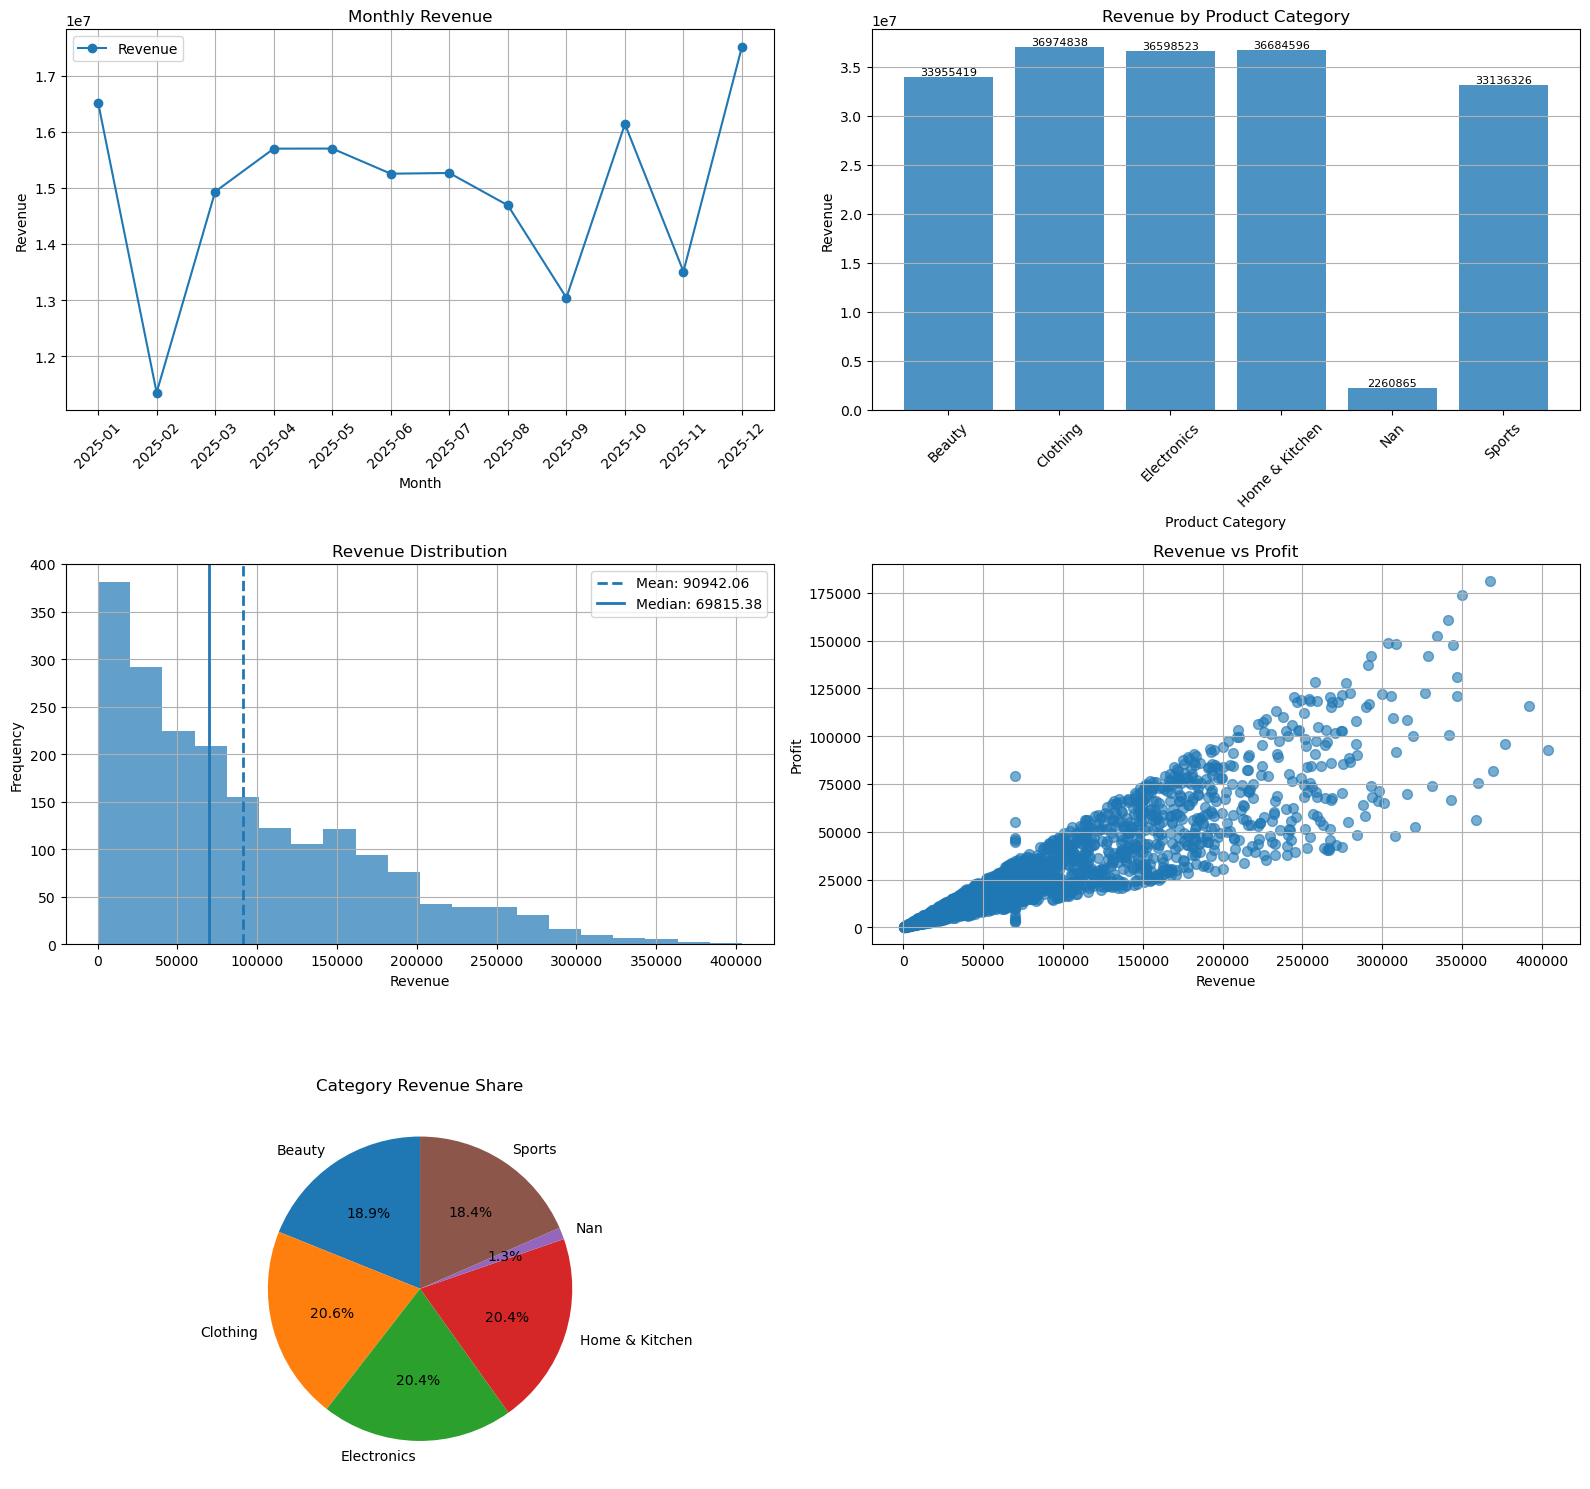

In [34]:
# ---------------------------------------
# 1. Prepare the data
# ---------------------------------------

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Monthly Revenue
monthly_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['revenue'].sum()

# Category Revenue
category_revenue = df.groupby(
    'product_category'
)['revenue'].sum()

# Mean and Median Revenue
mean_revenue = df['revenue'].mean()
median_revenue = df['revenue'].median()


# ---------------------------------------
# 2. Create 5-chart dashboard
# ---------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(16, 15))


# =======================================
# Chart 1: Monthly Revenue
# =======================================

axes[0, 0].plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o',
    linestyle='-',
    label='Revenue'
)

axes[0, 0].set_title('Monthly Revenue')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue')
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 0].tick_params(axis='x', rotation=45)


# =======================================
# Chart 2: Category Revenue
# =======================================

axes[0, 1].bar(
    category_revenue.index,
    category_revenue.values,
    alpha=0.8
)

axes[0, 1].set_title('Revenue by Product Category')
axes[0, 1].set_xlabel('Product Category')
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].grid(True, axis='y')

axes[0, 1].tick_params(axis='x', rotation=45)


# Add value labels above bars
for i, value in enumerate(category_revenue.values):
    axes[0, 1].text(
        i,
        value,
        f'{value:.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )


# =======================================
# Chart 3: Revenue Distribution
# =======================================

axes[1, 0].hist(
    df['revenue'].dropna(),
    bins=20,
    alpha=0.7
)

# Mean line
axes[1, 0].axvline(
    mean_revenue,
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_revenue:.2f}'
)

# Median line
axes[1, 0].axvline(
    median_revenue,
    linestyle='-',
    linewidth=2,
    label=f'Median: {median_revenue:.2f}'
)

axes[1, 0].set_title('Revenue Distribution')
axes[1, 0].set_xlabel('Revenue')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True)
axes[1, 0].legend()


# =======================================
# Chart 4: Revenue vs Profit
# =======================================

axes[1, 1].scatter(
    df['revenue'],
    df['profit'],
    s=50,
    alpha=0.6,
    marker='o'
)

axes[1, 1].set_title('Revenue vs Profit')
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Profit')
axes[1, 1].grid(True)


# =======================================
# Chart 5: Category Revenue Share
# =======================================

axes[2, 0].pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[2, 0].set_title('Category Revenue Share')


# =======================================
# Empty 6th subplot
# =======================================

axes[2, 1].axis('off')


# =======================================
# Final dashboard formatting
# =======================================

plt.tight_layout()

plt.show()